# _tobac_ example: multivariate tracking in ICON NextGEMS simulation

In this example, we will explore multivariate tracking of convective ice clouds in km-scale ICON simulations. This example will consist of the following sections:

  1. Accessing model data and conversion of healpix grid data to a regular lat/lon grid for tracking
  3. Feature detection, tracking, segmentation of (i) updrafts and (ii) ice clouds
  4. Combining the results of (i) and (ii) into overall convective ice clouds


In [1]:
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cf

import intake
import healpix
import easygems.healpix as egh

In [2]:
import tobac

In [3]:
tobac.multivariate

<module 'tobac.multivariate' from '/home/b/b382635/s/tobac/tobac/multivariate.py'>

In [4]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

## Data access and pre-processing

We start by accessing the online NextGEMS catalogue. The cycle 4 ICON model data is stored in healpix form, which is a hierarchichal format with multiple time and spatial resolution options:

In [5]:
cat = intake.open_catalog("https://data.nextgems-h2020.eu/catalog.yaml")
pd.DataFrame(cat.ICON.ngc4008a().describe()['user_parameters'])

,name,description,type,allowed,default
0,time,time resolution of the dataset,str,"[PT15M, PT3H, P1D]",P1D
1,zoom,zoom resolution of the dataset,int,"[9, 8, 7, 6, 5, 4, 3, 2, 1, 0]",0


In this example, we will use the highest zoom level available at 15 min resolution, zoom 9. We are also acessing cycle 4008a data, which provides 3D, rather than 2D dynamic and condensate fields.

In [6]:
zoom = 9
grid_spacing = 64 / 2**zoom
dxy = 1e5 * grid_spacing

In [7]:
icon_ds = cat.ICON.ngc4008a(time="PT15M", zoom=zoom).to_dask().sel(time=slice("20210702T0000","20210702T0800")).pipe(egh.attach_coords)

Text(0.5, 1.0, 'Cloud ice at approx.  11.6 km')

<Figure size 640x480 with 0 Axes>

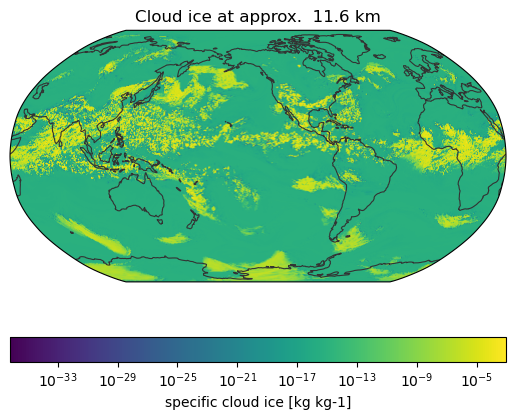

In [8]:
lvl = 50
img = egh.healpix_show(icon_ds.cli[0][lvl], norm=mpl.colors.LogNorm())
plt.colorbar(img, orientation="horizontal", label="specific cloud ice [kg kg-1]")
plt.title(f"Cloud ice at approx. {icon_ds.zg[lvl][0].item() * 1e-3: .1f} km")

To keep things simple, let's collapse that 3D information into 2D for tracking. Here, I've chosen levels that roughly correspond to where the maxima in vertical velocity and cloud ice occur

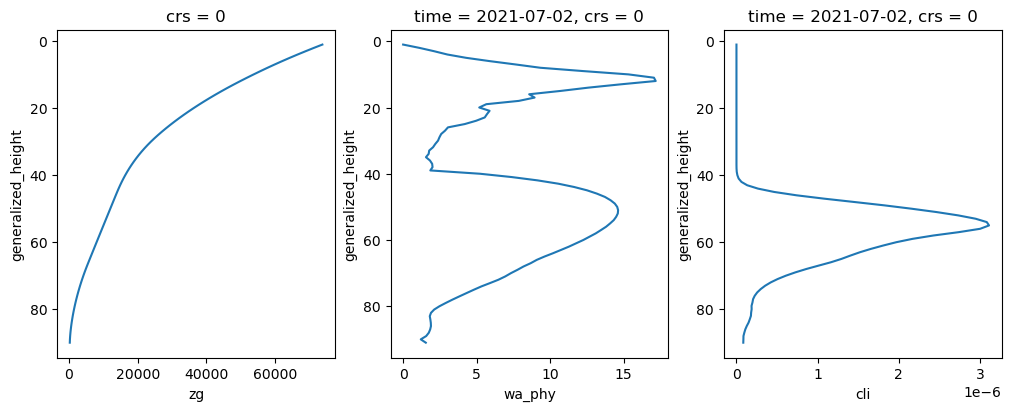

In [9]:
fig, axs = plt.subplots(1,3,figsize=(10,4), layout="constrained")

icon_ds.zg.mean('cell').plot(ax=axs[0], y="level_full")
icon_ds.wa_phy[0].max("cell").plot(ax=axs[1], y="level_half")
icon_ds.cli[0].mean("cell").plot(ax=axs[2], y="level_full")

for ax in axs:
    ax.invert_yaxis()

In [10]:
icon_ds = xr.Dataset({
    "w": icon_ds.wa_phy.sel(level_half=60, method="nearest"),
    "qi": icon_ds.cli.sel(level_full=52, method="nearest")
})

## Regrid ICON data to regular lat/lon grid for tracking:

The simplest approach to regridding is to use nearest neighbours after finding the cells matching a lat/lon grid using the `healpix.ang2pix` function:

In [11]:
def latlon_remap_cells(grid_spacing, crs):
    lon = xr.DataArray(
        np.arange(grid_spacing/2, 360, grid_spacing),
        dims=("lon",), 
        name="lon", 
        attrs=dict(units="degrees", standard_name="longitude")
    )
    lat = xr.DataArray(
        np.arange(90 - grid_spacing/2, -90, -grid_spacing), 
        dims=("lat",), 
        name="lat", 
        attrs=dict(units="degrees", standard_name="latitude")
    )

    return xr.DataArray(
        healpix.ang2pix(crs.healpix_nside, *np.meshgrid(lon, lat), nest=crs.healpix_order, lonlat=True),
        coords=(lat, lon),
    )


In [12]:
pix = latlon_remap_cells(grid_spacing, icon_ds.crs)

We can then perform the regridding using xarray's nearest neighbour selection:

In [13]:
icon_gridded = icon_ds.drop_vars(["lat", "lon"], errors="ignore").sel(cell=pix, method="nearest").drop_vars(["cell", "crs", "level_half", "level_full", "zg", "zghalf"], errors="ignore")

## Let's track the West Pacific only

Next, we're going to sub-sample the dataset, as the size of the global 3D data is much larger than we need to a nice demonstration. Let's track some convective ice clouds over the West Pacific.

In [14]:
# West Pacific warm pool
warm_pool = (90, 160, -10, 10)
pacific_ds = icon_gridded.sel(lat=slice(warm_pool[3], warm_pool[2]), lon=slice(warm_pool[0], warm_pool[1]))

In [15]:
pacific_ds

<xarray.Dataset> Size: 24MB
Dimensions:  (time: 33, lat: 160, lon: 560)
Coordinates:
  * time     (time) datetime64[ns] 264B 2021-07-02 ... 2021-07-02T08:00:00
  * lat      (lat) float64 1kB 9.938 9.812 9.688 9.562 ... -9.688 -9.812 -9.938
  * lon      (lon) float64 4kB 90.06 90.19 90.31 90.44 ... 159.7 159.8 159.9
Data variables:
    w        (time, lat, lon) float32 12MB ...
    qi       (time, lat, lon) float32 12MB ...

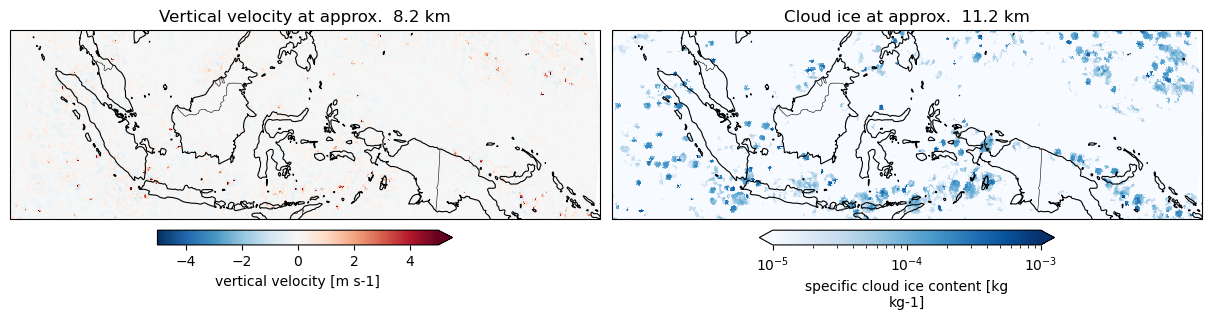

In [16]:
fig, axs = plt.subplots(1,2,figsize=(12,3), subplot_kw={"projection": ccrs.Robinson()}, constrained_layout=True)

ax = axs[0]
pacific_ds.w[0].plot(ax=ax, cmap="RdBu_r", norm=mpl.colors.TwoSlopeNorm(vmin=-5, vcenter=0, vmax=5), cbar_kwargs=dict(shrink=.5, orientation="horizontal"), transform=ccrs.PlateCarree())
ax.set_title(f"Vertical velocity at approx. {icon_ds.zghalf[0].item() * 1e-3: .1f} km")

ax = axs[1]
pacific_ds.qi[0].plot(ax=ax, cmap="Blues", norm=mpl.colors.LogNorm(vmin=1e-5, vmax=1e-3,), cbar_kwargs=dict(shrink=.5, orientation="horizontal"), transform=ccrs.PlateCarree())
ax.set_title(f"Cloud ice at approx. {icon_ds.zg[0].item() * 1e-3: .1f} km")

for ax in axs:
    ax.add_feature(cf.COASTLINE, linewidth=0.8)
    ax.add_feature(cf.BORDERS, linewidth=0.4)


## Feature detection and tracking using _tobac_

Now can make use of _tobac_ to track updrafts and ice clouds (seperately) in the data, using the steps:

1. feature_detection
2. tracking
3. segmentation

1. Start with feature detection using multiple thresholds

In [17]:
UpdraftFeatures = tobac.feature_detection_multithreshold(
    pacific_ds.w, 
    dxy=dxy,
    threshold=[1,2,3,4,5,6,7,8,9,10], 
)

In [18]:
IceCloudFeatures = tobac.feature_detection_multithreshold(
    pacific_ds.qi, 
    dxy=dxy, 
    threshold=[1e-5, 5e-5, 1e-4, 5e-4, 1e-3,], 
)

2. Track the features using predicted motion

In [19]:
UpdraftTracks = tobac.linking_trackpy(
    UpdraftFeatures, None, dt=900, dxy=dxy, d_max=dxy*2,
    method_linking="predict", stubs=2, 
    min_h2=0, max_h2=pacific_ds.lon.size
)

Frame 32: 135 trajectories present.


In [20]:
UpdraftTracks

,frame,idx,hdim_1,hdim_2,num,threshold_value,feature,time,timestr,lat,lon,cell,time_cell
0,0,1,0.0,364.0,1,1,1,2021-07-02 00:00:00,2021-07-02 00:00:00,9.9375,135.5625,1,0 days 00:00:00
1,0,2,1.0,508.0,5,1,2,2021-07-02 00:00:00,2021-07-02 00:00:00,9.8125,153.5625,2,0 days 00:00:00
2,0,5,7.5,321.0,4,1,3,2021-07-02 00:00:00,2021-07-02 00:00:00,9.0000,130.1875,-1,NaT
3,0,7,11.0,438.0,1,1,4,2021-07-02 00:00:00,2021-07-02 00:00:00,8.5625,144.8125,4,0 days 00:00:00
4,0,8,11.5,522.0,2,1,5,2021-07-02 00:00:00,2021-07-02 00:00:00,8.5000,155.3125,5,0 days 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3027,32,293,131.0,316.0,1,5,3028,2021-07-02 08:00:00,2021-07-02 08:00:00,-6.4375,129.5625,-1,NaT
3028,32,295,149.0,523.5,2,5,3029,2021-07-02 08:00:00,2021-07-02 08:00:00,-8.6875,155.5000,667,0 days 01:45:00
3029,32,298,124.0,160.5,2,6,3030,2021-07-02 08:00:00,2021-07-02 08:00:00,-5.5625,110.1250,849,0 days 00:15:00
3030,32,299,137.0,153.5,2,6,3031,2021-07-02 08:00:00,2021-07-02 08:00:00,-7.1875,109.2500,765,0 days 01:00:00


In [21]:
IceCloudTracks = tobac.linking_trackpy(
    IceCloudFeatures, None, dt=900, dxy=dxy, d_max=dxy*4, 
    method_linking="predict", stubs=2, 
    min_h2=0, max_h2=pacific_ds.lon.size
)

Frame 32: 497 trajectories present.


In [22]:
IceCloudTracks

,frame,idx,hdim_1,hdim_2,num,threshold_value,feature,time,timestr,lat,lon,cell,time_cell
0,0,1,3.200000,0.850000,20,0.00001,1,2021-07-02 00:00:00,2021-07-02 00:00:00,9.537500,90.168750,1,0 days 00:00:00
1,0,2,1.500000,6.333333,6,0.00001,2,2021-07-02 00:00:00,2021-07-02 00:00:00,9.750000,90.854167,-1,NaT
2,0,4,1.933333,265.266667,15,0.00001,3,2021-07-02 00:00:00,2021-07-02 00:00:00,9.695833,123.220833,3,0 days 00:00:00
3,0,9,0.444444,383.222222,9,0.00001,4,2021-07-02 00:00:00,2021-07-02 00:00:00,9.881944,137.965278,4,0 days 00:00:00
4,0,10,0.777778,390.666667,9,0.00001,5,2021-07-02 00:00:00,2021-07-02 00:00:00,9.840278,138.895833,5,0 days 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14694,32,829,85.500000,179.500000,4,0.00050,14695,2021-07-02 08:00:00,2021-07-02 08:00:00,-0.750000,112.500000,-1,NaT
14695,32,830,107.000000,98.500000,2,0.00050,14696,2021-07-02 08:00:00,2021-07-02 08:00:00,-3.437500,102.375000,-1,NaT
14696,32,831,111.500000,80.500000,2,0.00050,14697,2021-07-02 08:00:00,2021-07-02 08:00:00,-4.000000,100.125000,-1,NaT
14697,32,832,118.000000,146.000000,1,0.00050,14698,2021-07-02 08:00:00,2021-07-02 08:00:00,-4.812500,108.312500,3462,0 days 00:15:00


3. perform a watershed segmentation to find the area surrounding each feature to the min threshold

In [23]:
updraft_mask, UpdraftTracks = tobac.segmentation.segmentation(
    UpdraftTracks, 
    pacific_ds.w, 
    dxy=dxy, 
    threshold=1, 
    seed_3D_flag="box"
)

In [24]:
ice_cloud_mask, IceCloudTracks = tobac.segmentation.segmentation(
    IceCloudTracks, 
    pacific_ds.qi, 
    dxy=dxy, 
    threshold=1e-5, 
    seed_3D_flag="box"
)

Finally, add the tracking labels to the watershed masks

In [25]:
def table_to_dataset(table, name, dataset, existing_var="feature"):
    di = table.set_index(existing_var)[name].to_dict()
    feature_array = dataset[existing_var].values
    dataarray = xr.DataArray(np.vectorize(lambda x: di.get(x, 0))(feature_array), dims=dataset[existing_var].dims, coords=dataset[existing_var].coords)
    return dataarray

updraft_mask = updraft_mask.to_dataset(name="feature")
updraft_mask['cell'] = table_to_dataset(table=UpdraftTracks, name='cell', dataset=updraft_mask)

In [26]:
ice_cloud_mask = ice_cloud_mask.to_dataset(name="feature")
ice_cloud_mask['cell'] = table_to_dataset(table=IceCloudTracks, name='cell', dataset=ice_cloud_mask)

View the results

Text(0.5, 1.0, 'tobac tracked ice clouds')

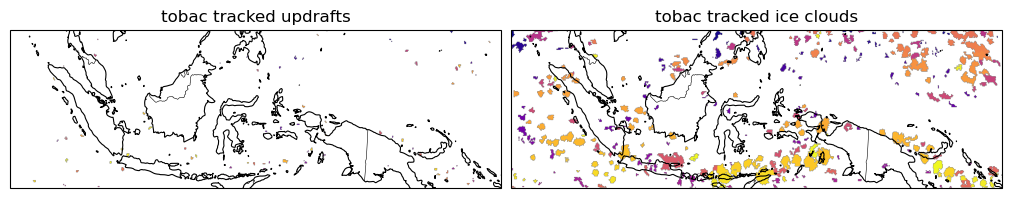

In [27]:
fig, axs = plt.subplots(1,2, figsize=(10,2.5), subplot_kw={"projection": ccrs.Robinson()}, layout="constrained")
for ax in axs:
    ax.set_extent(warm_pool, crs=ccrs.PlateCarree())
    ax.add_feature(cf.COASTLINE, linewidth=0.8)
    ax.add_feature(cf.BORDERS, linewidth=0.4)
t = 0
axs[0].imshow(
    updraft_mask.cell[t].where(updraft_mask.cell[t]>0), cmap="plasma",
    extent=warm_pool, transform=ccrs.PlateCarree(),
)
axs[0].set_title("tobac tracked updrafts")
axs[1].imshow(
    ice_cloud_mask.cell[t].where(ice_cloud_mask.cell[t]>0), cmap="plasma",
    extent=warm_pool, transform=ccrs.PlateCarree(),
)
axs[1].set_title("tobac tracked ice clouds")

## Combining the multivariate tracking information

Great. Now we have two sets of tracking results, one the follows the evolution of (i) updrafts and another that follows (ii) ice clodus over the West Pacific. 
To get to __convective__ ice clouds we want to search for all the updrafts associated with each ice clouds and link them up into one nice overall system.

To do this, we need to:

1. Calculate the labels maps that transform each updraft track to the coincident ice cloud track
2. Apply those mappings

1. Start by finding out which updrafts were associated with each ice cloud

In [28]:
UpdraftTracksMV, IceCloudTracksMV = tobac.multivariate.get_multivariate_label_maps(updraft_mask.cell, UpdraftTracks, ice_cloud_mask.cell, IceCloudTracks)

In [29]:
UpdraftTracksMV

,frame,idx,hdim_1,hdim_2,num,threshold_value,feature,time,timestr,lat,lon,cell,time_cell,ncells,multivariate
0,0,1,0.0,364.0,1,1,1,2021-07-02 00:00:00,2021-07-02 00:00:00,9.9375,135.5625,1,0 days 00:00:00,2,269
1,0,2,1.0,508.0,5,1,2,2021-07-02 00:00:00,2021-07-02 00:00:00,9.8125,153.5625,2,0 days 00:00:00,5,271
2,0,5,7.5,321.0,4,1,3,2021-07-02 00:00:00,2021-07-02 00:00:00,9.0000,130.1875,0,NaT,5,0
3,0,7,11.0,438.0,1,1,4,2021-07-02 00:00:00,2021-07-02 00:00:00,8.5625,144.8125,4,0 days 00:00:00,3,282
4,0,8,11.5,522.0,2,1,5,2021-07-02 00:00:00,2021-07-02 00:00:00,8.5000,155.3125,5,0 days 00:00:00,5,288
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3027,32,293,131.0,316.0,1,5,3028,2021-07-02 08:00:00,2021-07-02 08:00:00,-6.4375,129.5625,0,NaT,4,0
3028,32,295,149.0,523.5,2,5,3029,2021-07-02 08:00:00,2021-07-02 08:00:00,-8.6875,155.5000,667,0 days 01:45:00,4,2551
3029,32,298,124.0,160.5,2,6,3030,2021-07-02 08:00:00,2021-07-02 08:00:00,-5.5625,110.1250,849,0 days 00:15:00,6,3126
3030,32,299,137.0,153.5,2,6,3031,2021-07-02 08:00:00,2021-07-02 08:00:00,-7.1875,109.2500,765,0 days 01:00:00,5,3267


We can already get some useful information from the results

Text(0.5, 1.0, 'Number of updrafts per ice cloud')

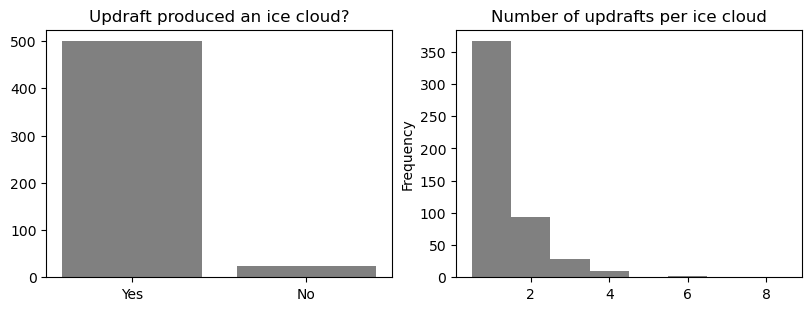

In [30]:
n_updrafts = UpdraftTracksMV[["cell","multivariate"]].groupby("multivariate").nunique()
n_per_cloud = n_updrafts.iloc[1:]
n_no_cloud = n_updrafts.iloc[0].cell

fig, axs = plt.subplots(1,2, figsize=(8,3), layout="constrained")

axs[0].bar(["Yes", "No"],[n_per_cloud.size, n_no_cloud], color="grey",)
axs[0].set_title("Updraft produced an ice cloud?")

n_per_cloud.cell.plot.hist(ax=axs[1], bins=np.arange(1,10,1), color="grey", align="left")
axs[1].set_title("Number of updrafts per ice cloud")

We can also see that a small number of updrafts actually fed two different ice clouds, which usually means there was a jump or a merge in the ice cloud tracking. Using this information, we can merge those ice clouds that were actually fed by the same updraft

In [31]:
n_merged_per_cloud = IceCloudTracksMV[["cell","multivariate"]].groupby("multivariate").nunique().iloc[1:]
print("there were", (n_merged_per_cloud>1).cell.sum(), "ice clouds that shared an updraft with another tracked cloud")

there were 77 ice clouds that shared an updraft with another tracked cloud


2. Finally, we can apply the results to the segmentation masks

In [32]:
final_updraft_mask, final_ice_cloud_mask = tobac.multivariate.apply_multivariate_label_maps(updraft_mask.cell, UpdraftTracksMV, ice_cloud_mask.cell, IceCloudTracksMV)

Let's check the behaviour of the ice cloud merging in response to a shared updraft

In [33]:
anvil_id = 243 
merging_example = final_ice_cloud_mask.where(final_ice_cloud_mask==anvil_id).isel(time=slice(8,13)).dropna('time', how='all').dropna('lat', how='all').dropna('lon', how='all')
initial_w_tracks = updraft_mask.cell.sel(merging_example.coords).where(merging_example>0)
initial_qi_tracks = ice_cloud_mask.cell.sel(merging_example.coords).where(merging_example>0)

We can see below how the anvil was previously split into two seperate tracks, but has now been merged by the shared convective updraft

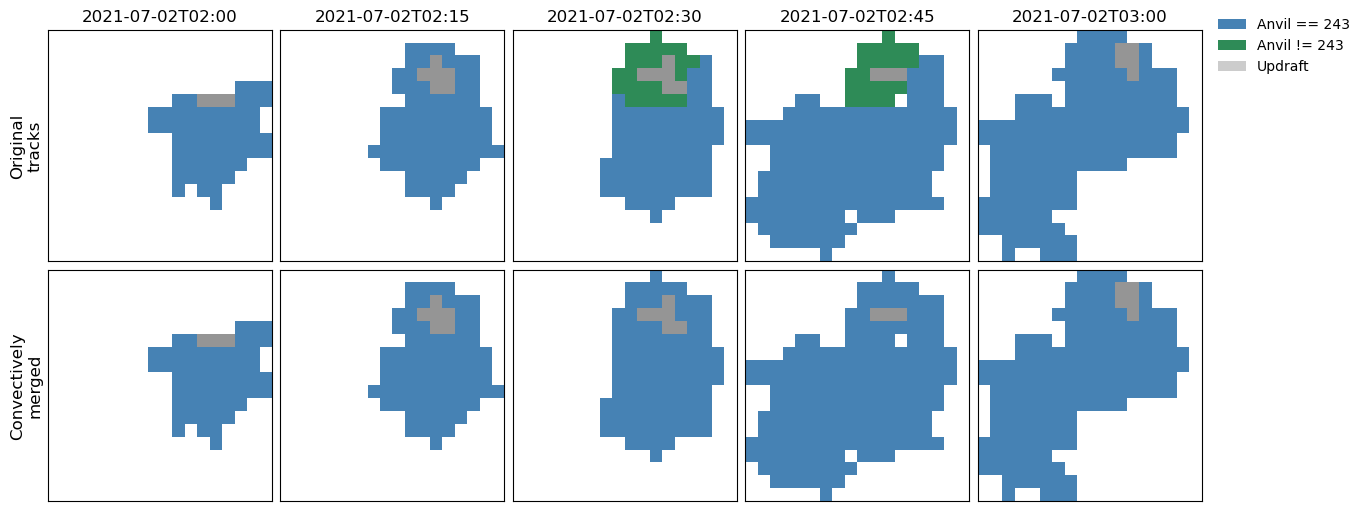

In [34]:

times = merging_example.time.values
cmap = mpl.colors.ListedColormap(["steelblue","seagreen"])
params = dict(vmin=243, vmax=244, cmap=cmap, add_colorbar=0, alpha=1)

fig, axs = plt.subplots(2,5, figsize=(12,5), layout="constrained", sharex=1, sharey=1)

for i,t in enumerate(times):
    initial_qi_tracks.sel(time=t).plot(ax=axs[0,i], **params)
    (initial_w_tracks>0).where(initial_w_tracks>0).sel(time=t).plot(ax=axs[0,i], cmap="Greys", add_colorbar=0, )
    axs[0,i].set_title(np.datetime_as_string(t, unit="m"),)

for i,t in enumerate(times):
    merging_example.sel(time=t).plot(ax=axs[1,i], **params)
    (initial_w_tracks>0).where(initial_w_tracks>0).sel(time=t).plot(ax=axs[1,i], cmap="Greys", add_colorbar=0, )
    axs[1,i].set_title(None)

for ax in axs.ravel():
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_yticks([])

axs[0, 0].set_ylabel("Original\ntracks", fontsize=12)
axs[1, 0].set_ylabel("Convectively\nmerged", fontsize=12)

legend_handles = [mpl.patches.Patch(facecolor="steelblue", label=f"Anvil == {anvil_id}"), 
                  mpl.patches.Patch(facecolor="seagreen", label=f"Anvil != {anvil_id}"), 
                  mpl.patches.Patch(facecolor="grey", alpha=0.4, label="Updraft"),]

fig.legend(handles=legend_handles, loc="upper left", frameon=False, bbox_to_anchor=(1,1))


## Analysis of tracked convective ice clouds

Now we can derive statistics related to both the updraft and ice cloud evolution, and how each impacts the other

In [35]:
UpdraftTracksMV = tobac.calculate_area(UpdraftTracksMV, updraft_mask.feature, method_area="latlon", )
UpdraftTracksMV = tobac.utils.bulk_statistics.get_statistics_from_mask(
    UpdraftTracksMV, updraft_mask.feature, pacific_ds.w, statistic={"max_w": np.nanmax, }, default=np.nan
)

IceCloudTracksMV = tobac.calculate_area(IceCloudTracksMV, ice_cloud_mask.feature, method_area="latlon", )

/home/b/b382635/.conda/envs/WCRP25_hackathon/lib/python3.12/site-packages/iris/analysis/cartography.py:435: IrisDefaultingWarning: Using DEFAULT_SPHERICAL_EARTH_RADIUS.
  warnings.warn(
/home/b/b382635/.conda/envs/WCRP25_hackathon/lib/python3.12/site-packages/iris/analysis/cartography.py:435: IrisDefaultingWarning: Using DEFAULT_SPHERICAL_EARTH_RADIUS.
  warnings.warn(


In [36]:
IceCloudTracksMV

,frame,idx,hdim_1,hdim_2,num,threshold_value,feature,time,timestr,lat,lon,cell,time_cell,ncells,multivariate,area
0,0,1,3.200000,0.850000,20,0.00001,1,2021-07-02 00:00:00,2021-07-02 00:00:00,9.537500,90.168750,1,0 days 00:00:00,21,0,3.996546e+09
1,0,2,1.500000,6.333333,6,0.00001,2,2021-07-02 00:00:00,2021-07-02 00:00:00,9.750000,90.854167,0,NaT,8,0,1.521666e+09
2,0,4,1.933333,265.266667,15,0.00001,3,2021-07-02 00:00:00,2021-07-02 00:00:00,9.695833,123.220833,3,0 days 00:00:00,16,0,3.043613e+09
3,0,9,0.444444,383.222222,9,0.00001,4,2021-07-02 00:00:00,2021-07-02 00:00:00,9.881944,137.965278,4,0 days 00:00:00,9,0,1.711036e+09
4,0,10,0.777778,390.666667,9,0.00001,5,2021-07-02 00:00:00,2021-07-02 00:00:00,9.840278,138.895833,5,0 days 00:00:00,8,0,1.521024e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14694,32,829,85.500000,179.500000,4,0.00050,14695,2021-07-02 08:00:00,2021-07-02 08:00:00,-0.750000,112.500000,0,NaT,8,0,1.543675e+09
14695,32,830,107.000000,98.500000,2,0.00050,14696,2021-07-02 08:00:00,2021-07-02 08:00:00,-3.437500,102.375000,0,NaT,54,0,1.040430e+10
14696,32,831,111.500000,80.500000,2,0.00050,14697,2021-07-02 08:00:00,2021-07-02 08:00:00,-4.000000,100.125000,0,NaT,10,0,1.924898e+09
14697,32,832,118.000000,146.000000,1,0.00050,14698,2021-07-02 08:00:00,2021-07-02 08:00:00,-4.812500,108.312500,3462,0 days 00:15:00,9,3462,1.730677e+09


Let's collect some bulk statistics from each set, and have a look at the resulting relationships

In [37]:
max_updraft_properties = UpdraftTracksMV[["multivariate","area","max_w"]].groupby("multivariate").max().rename(columns={"area":"w_area"})
max_area = IceCloudTracksMV[["multivariate","area"]].groupby("multivariate").max()
convective_cloud_stats = max_area.merge(max_updraft_properties, on="multivariate")

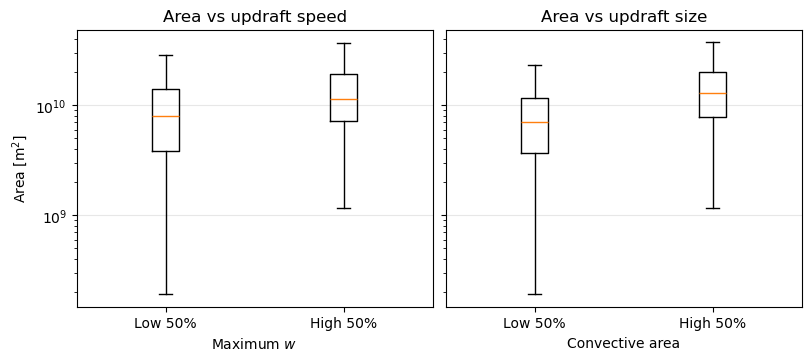

In [38]:
fig, axs = plt.subplots(1,2, figsize=(8, 3.5), layout="constrained", sharey=True,)

# area ds w_max
ax = axs[0]
median_w = convective_cloud_stats.max_w.median()
low_w = convective_cloud_stats.loc[convective_cloud_stats.max_w <= median_w, "area"].dropna()
high_w = convective_cloud_stats.loc[convective_cloud_stats.max_w > median_w, "area"].dropna()

ax.boxplot([low_w, high_w], tick_labels=["Low 50%", "High 50%"], showfliers=False)
ax.set_title("Area vs updraft speed")
ax.set_xlabel("Maximum $w$")
ax.set_ylabel(r"Area [m$^2$]")

# area vs w_area
ax = axs[1]
median_area = convective_cloud_stats.w_area.median()
small = convective_cloud_stats.loc[convective_cloud_stats.w_area <= median_area, "area"].dropna()
large = convective_cloud_stats.loc[convective_cloud_stats.w_area > median_area, "area"].dropna()
ax.boxplot([small, large], tick_labels=["Low 50%", "High 50%"], showfliers=False)
ax.set_title("Area vs updraft size")
ax.set_xlabel("Convective area")

for ax in axs:
    ax.grid(axis="y", alpha=0.3)

for ax in axs:
    ax.set_yscale("log")